In [30]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [32]:
# Loading the dataset
df = pd.read_csv('Nagpur_dataset - foo2014-2022.csv')

# Displaying first few rows
print("Dataset Preview:")
print(df.head())

Dataset Preview:
         date         location  valid_time_gmt     month      time  \
0  20140102.0  Nagpur/Sonegaon    1.388602e+09  January    6:40 PM   
1  20140102.0  Nagpur/Sonegaon    1.388605e+09  January    7:40 PM   
2  20140102.0  Nagpur/Sonegaon    1.388609e+09  January    8:40 PM   
3  20140102.0  Nagpur/Sonegaon    1.388612e+09  January    9:40 PM   
4  20140102.0  Nagpur/Sonegaon    1.388616e+09  January   10:40 PM   

  (Day/Night)  temperature condition  dewPoint  heat_index  ...  wdirection  \
0           N         63.0      Fair      54.0        63.0  ...       350.0   
1           N         63.0      Fair      52.0        63.0  ...        20.0   
2           N         61.0      Fair      52.0        61.0  ...         NaN   
3           N         61.0      Fair      54.0        61.0  ...         NaN   
4           N         55.0      Fair      50.0        55.0  ...         NaN   

   wdir_cardinal  gust  wspd  uv_desc feels_like  uv_index  clds   rain  \
0           

In [34]:
# Data Preprocessing

# Converting date to datetime
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

# Handling missing or invalid values
df = df.replace('', np.nan)
df = df.dropna(subset=['temperature', 'humidity %', 'pressure', 'visibility', 'wspd'])

# Converting columns to appropriate types
numeric_cols = ['temperature', 'dewPoint', 'heat_index', 'humidity %', 'pressure', 'visibility', 'windchill', 'wspd', 'gust', 'uv_index']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filling missing numeric values with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Encoding categorical variables
le_condition = LabelEncoder()
le_wdir = LabelEncoder()
le_clds = LabelEncoder()
le_daynight = LabelEncoder()

df['condition_encoded'] = le_condition.fit_transform(df['condition'].astype(str))
df['wdir_cardinal_encoded'] = le_wdir.fit_transform(df['wdir_cardinal'].astype(str))
df['clds_encoded'] = le_clds.fit_transform(df['clds'].astype(str))
df['daynight_encoded'] = le_daynight.fit_transform(df['(Day/Night)'].astype(str))

# Feature engineering
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['hour'] = pd.to_datetime(df['time'], format='%I:%M %p').dt.hour

# Selecting features and target
features = ['month', 'hour', 'daynight_encoded', 'humidity %', 'pressure', 'visibility', 'wspd', 'condition_encoded', 'wdir_cardinal_encoded', 'clds_encoded']
target = 'temperature'

X = df[features]
y = df[target]

print("Features selected:", features)
print("Target variable:", target)

Features selected: ['month', 'hour', 'daynight_encoded', 'humidity %', 'pressure', 'visibility', 'wspd', 'condition_encoded', 'wdir_cardinal_encoded', 'clds_encoded']
Target variable: temperature


In [36]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (89181, 10)
Testing set shape: (22296, 10)


In [38]:
# Training the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


Model Performance Metrics:
Mean Squared Error (MSE): 6.13
Root Mean Squared Error (RMSE): 2.48
Mean Absolute Error (MAE): 1.73
R2 Score: 0.95


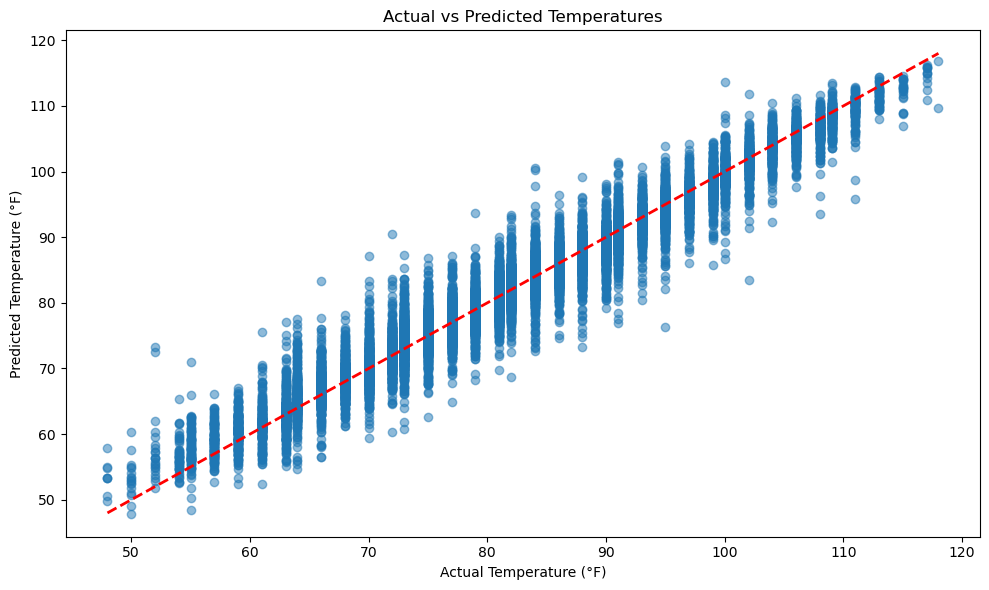

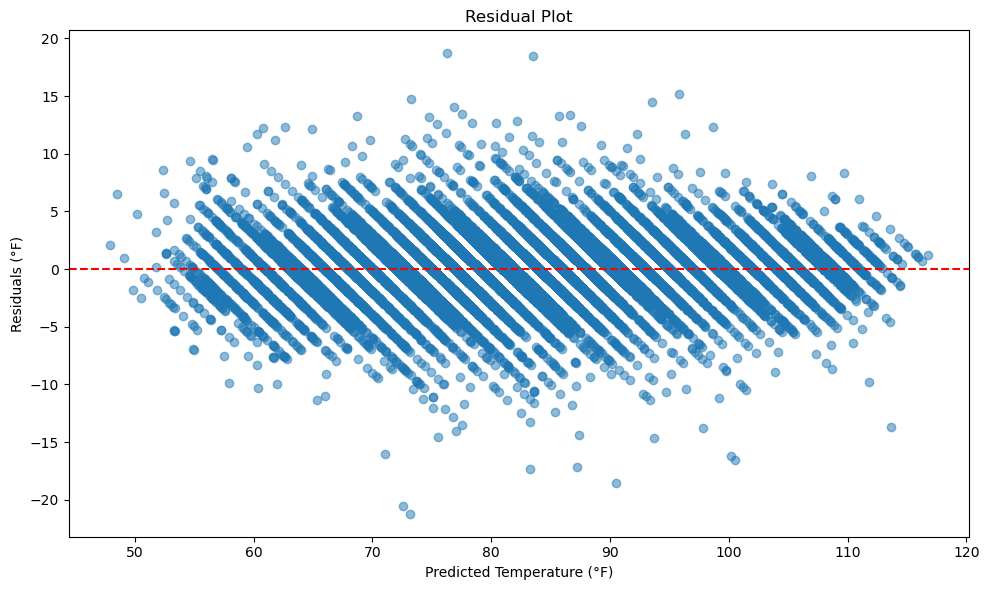

In [42]:
# Evaluating the model with additional metrics and visualizations
y_pred = rf_model.predict(X_test)

# Calculating metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

# Plotting actual vs predicted temperatures
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°F)')
plt.ylabel('Predicted Temperature (°F)')
plt.title('Actual vs Predicted Temperatures')
plt.tight_layout()
plt.show()

# Plotting residual plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Temperature (°F)')
plt.ylabel('Residuals (°F)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [44]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
                 Feature  Importance
3             humidity %    0.504883
4               pressure    0.224001
0                  month    0.098607
1                   hour    0.087671
2       daynight_encoded    0.037699
8  wdir_cardinal_encoded    0.012941
9           clds_encoded    0.011582
5             visibility    0.010756
6                   wspd    0.008600
7      condition_encoded    0.003260


In [46]:
# Saving the model and encoders
model_data = {
    'model': rf_model,
    'le_condition': le_condition,
    'le_wdir': le_wdir,
    'le_clds': le_clds,
    'le_daynight': le_daynight
}

with open('weather_prediction_model.pkl', 'wb') as file:
    pickle.dump(model_data, file)

print("Model and encoders saved to 'weather_prediction_model.pkl'")

Model and encoders saved to 'weather_prediction_model.pkl'


In [54]:
# Example: Predicting for a new data point
# Creating a sample input (modify as needed)
sample_input = pd.DataFrame({
    'month': [4],
    'hour': [14],
    'daynight_encoded': [le_daynight.transform(['N'])[0]],
    'humidity %': [40],
    'pressure': [28.7],
    'visibility': [2],
    'wspd': [5],
    'condition_encoded': [le_condition.transform(['Haze'])[0]],
    'wdir_cardinal_encoded': [le_wdir.transform(['E'])[0]],
    'clds_encoded': [le_clds.transform(['SCT'])[0]]
})

predicted_temp = rf_model.predict(sample_input)
print(f"Predicted Temperature: {predicted_temp[0]:.2f}°F")

Predicted Temperature: 90.42°F
